# RFM-анализ клиентов (Olist E-commerce)

Цель проекта — сегментировать клиентов по Recency, Frequency и Monetary метрикам с помощью SQL (CTE, оконные функции NTILE) и проанализировать сегменты в Python (pandas, matplotlib).

## 1. SQL: расчёт RFM-метрик

Метрики (Recency, Frequency, Monetary) и сегменты рассчитаны на стороне БД (MS SQL) с использованием CTE и оконной функции NTILE(4) для разбивки клиентов на квартили по каждой метрике. Результат выгружен в CSV для дальнейшего анализа в Python.

## 2. Загрузка данных в Python

In [21]:
import pandas as pd
df = pd.read_csv('olis_results.csv', sep=';')

In [22]:
df

,customer_id,total_spent,order_count,recency,rfm_segment
0,a4b417188addbc05b26b72d5e44837a1,89.71,1,1,331
1,856336203359aa6a61bf3826f7d84c49,222.03,1,2,111
2,4c2ec60c29d10c34bd49cb88aa85cfc4,197.55,1,15,111
3,bf6181a85bbb4115736c0a8db1a53be3,80.38,1,17,331
4,2823ffda607a2316375088e0d00005ec,137.03,1,19,221
...,...,...,...,...,...
99435,6f989332712d3222b6571b1cf5b835ce,53.73,1,745,444
99436,b106b360fe2ef8849fbbd056f777b4d5,109.34,1,746,224
99437,622e13439d6b5a0b486c435618b2679e,40.95,1,765,444
99438,683c54fc24d40ee9f8a6fc179fd9856c,75.06,1,773,334


## 3. Размер сегментов

In [23]:
df['rfm_segment'].value_counts()

rfm_segment
444    6409
334    6407
221    6364
111    6363
333    6317
222    6303
442    6234
223    6231
113    6209
112    6206
332    6117
441    6114
443    6103
114    6082
331    6019
224    5962
Name: count, dtype: int64

**Наблюдение**: сегменты распределены довольно равномерно (~6000-6400 клиентов каждый). Сегмент "444" (низкий чек, низкая частота, давняя последняя покупка) — самый крупный, что типично для e-commerce с большой долей разовых покупателей.

## 4. Средние показатели по сегментам

In [24]:
df.groupby('rfm_segment')[['total_spent', 'recency', 'order_count']].mean()

,total_spent,recency,order_count
rfm_segment,,,
111,391.526038,109.602389,1.0
112,366.763274,218.586046,1.0
113,375.598401,332.099855,1.0
114,393.724148,507.884742,1.0
221,137.327703,109.613136,1.0
222,138.323322,218.960019,1.0
223,137.203250,330.513240,1.0
224,136.466355,505.892486,1.0
331,81.920367,107.408207,1.0


**Наблюдение**: order_count везде равен 1.0 — большинство клиентов в датасете совершили только одну покупку, поэтому Frequency-метрика малоинформативна для этого датасета. При этом total_spent чётко убывает от сегмента "1xx" (390 BRL) до "4xx" (43 BRL), подтверждая, что m_score корректно ранжирует клиентов по сумме покупок.

In [25]:
import matplotlib.pyplot as plt

## 5. Визуализация: средний чек по сегментам

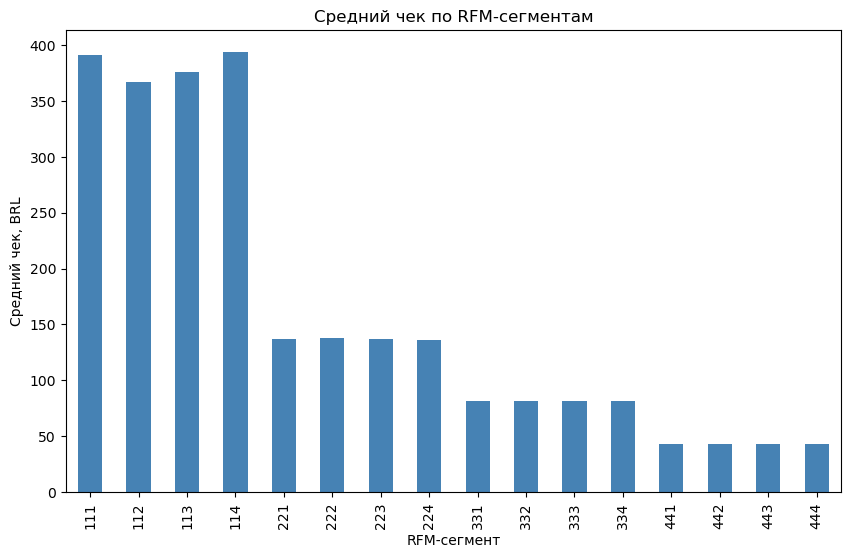

In [31]:
segment_means = df.groupby('rfm_segment')[['total_spent', 'recency', 'order_count']].mean()
segment_means['total_spent'].plot(kind='bar', figsize=(10,6), color='steelblue')
plt.title('Средний чек по RFM-сегментам')
plt.xlabel('RFM-сегмент')
plt.ylabel('Средний чек, BRL')
plt.show()

## Выводы

- RFM-сегментация на основе SQL (CTE + NTILE) успешно разбила 99 440 клиентов на 16 групп по комбинации Recency, Frequency, Monetary
- Сегмент "111" ("Champions" — недавняя покупка, высокий чек) показывает средний чек ~390 BRL, в то время как "444" ("Lost") — около 43 BRL, разница почти в 9 раз
- В данном датасете Frequency не варьируется (order_count ≈ 1 для всех), поэтому в реальном продукте с повторными покупками сегментация дала бы более выраженные группы по этой метрике
- Возможные следующие шаги: A/B-тест реактивационной кампании для сегмента "444", анализ товарных категорий по сегментам "111"